## STAT 306 Project: Vancouver Land Value Associated with Prior Year Values and Age

In [52]:
library(tidyverse)
library(dplyr)
library(broom)
library(ggplot2)
library(car)
library(GGally)
library(broom)

--------------------------
#### Data cleaning

In [53]:
property <- read.csv(
  file = "./data/sample_data.csv"
) |>
  subset(select = c(CURRENT_LAND_VALUE,
    PREVIOUS_LAND_VALUE,
    PREVIOUS_IMPROVEMENT_VALUE,
    YEAR_BUILT, ZONING_CLASSIFICATION,
    LEGAL_TYPE
  )) |>
  na.omit()

property2 <- subset(property,
  is.finite(CURRENT_LAND_VALUE) & CURRENT_LAND_VALUE > 0 &
  is.finite(PREVIOUS_LAND_VALUE) & PREVIOUS_LAND_VALUE > 0 &
  is.finite(PREVIOUS_IMPROVEMENT_VALUE) & PREVIOUS_IMPROVEMENT_VALUE > 0 &
  is.finite(YEAR_BUILT)
)


nrow(property) - nrow(property2) ## we check how many rows were dropped
sample_n(property, 10) ## looking at our data


[1] 4

CURRENT_LAND_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,ZONING_CLASSIFICATION,LEGAL_TYPE
<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
433000,440000,58800,1974,Residential,STRATA
441000,475000,162000,1999,Comprehensive Development,STRATA
599000,598000,281000,2003,Comprehensive Development,STRATA
376000,316000,299000,1991,Comprehensive Development,STRATA
707000,693000,172000,1997,Commercial,STRATA
1384000,1191000,33400,1954,One-Family Dwelling,LAND
1824000,1843000,56300,1948,Residential Inclusive,LAND
432000,391000,269000,2018,Comprehensive Development,STRATA
1795000,1615000,321000,2005,One-Family Dwelling,LAND


In [54]:
# See how many variables in ZONING CLASSIFICATION

unique(property$ZONING_CLASSIFICATION)
length(unique(property$ZONING_CLASSIFICATION))

[1] "Residential Inclusive"     "One-Family Dwelling"      
 [3] "Comprehensive Development" "Industrial"               
 [5] "Commercial"                "Multiple Dwelling"        
 [7] "Residential"               "Two-Family Dwelling"      
 [9] "Historical Area"           "Other"                    
[11] ""                          "Limited Agriculture"

[1] 12

In [55]:
# See what missing values in ZONING CLASSIFICATION

property[property$ZONING_CLASSIFICATION == '',]

,CURRENT_LAND_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,ZONING_CLASSIFICATION,LEGAL_TYPE
,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
175,537000,609000,145000,2017,,STRATA
605,320000,310000,166000,2018,,STRATA
991,1523000,1811000,126000,1983,,LAND
1511,494000,551000,298000,2018,,STRATA
1676,520000,503000,281000,2018,,STRATA
1890,300000,350000,187000,2018,,STRATA
1946,420000,491000,261000,2018,,STRATA
1985,732000,822000,349000,2017,,STRATA


In [56]:
# Simplify ZONING CLASSIFICATION into 5 categories: Residential, Commercial, Industrial, Agriculture, Special

property2$ZONE_SIMPLE <- dplyr::case_when(
  property2$ZONING_CLASSIFICATION %in% c(
    "Residential Inclusive",
    "One-Family Dwelling",
    "Two-Family Dwelling",
    "Multiple Dwelling",
    "Residential"
  ) ~ "Residential",

  property2$ZONING_CLASSIFICATION == "Commercial" ~ "Commercial",

  property2$ZONING_CLASSIFICATION == "Industrial" ~ "Industrial",

  property2$ZONING_CLASSIFICATION == "Limited Agriculture" ~ "Agriculture",
  property2$ZONING_CLASSIFICATION %in% c(
    "Comprehensive Development",
    "Historical Area",
    "",
    "Other"
  ) ~ "Special"
)

In [57]:
unique(property$ZONE_SIMPLE)
length(unique(property$ZONE_SIMPLE))

NULL

[1] 0

In [58]:
colSums(is.na(property))

CURRENT_LAND_VALUE        PREVIOUS_LAND_VALUE 
                         0                          0 
PREVIOUS_IMPROVEMENT_VALUE                 YEAR_BUILT 
                         0                          0 
     ZONING_CLASSIFICATION                 LEGAL_TYPE 
                         0                          0

In [59]:
table(property2$LEGAL_TYPE)
## there is only one OTHER legal type so we decicded to drop it as outlier
nrow(property2)  


  LAND  OTHER STRATA 
   755      1   1143 

[1] 1899

In [60]:
property2 <- property2[property2$LEGAL_TYPE != "OTHER", ]
nrow(property2)  # should be 1 less than before

[1] 1898

--------------------------
#### Fitting Models

In [61]:
fit <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE, data = property2)
bb <- coef(fit)
# bb
fit_both <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE + LEGAL_TYPE, data = property2)
fit_legal <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + LEGAL_TYPE, data = property2)
fit_inter <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE)*LEGAL_TYPE + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property2)
cat("Additive Model with ZONE_SIMPLE")
summary(fit)
cat(" \n \n Additive Model with LEGAL_TYPE")
summary(fit_legal)
cat("\n \n Additive Model with both ZONE_SIMPLE and LEGAL_TYPE")
summary(fit_both)
cat("\n \n Interaction Model with log(PREVIOUS_LAND_VALUE) and LEGAL_TYPE")
summary(fit_inter)

Additive Model with ZONE_SIMPLE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59786 -0.05413  0.00545  0.05920  0.62919 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.0172439  0.2155271   4.720 2.53e-06 ***
log(PREVIOUS_LAND_VALUE)         0.9780066  0.0030939 316.108  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0073671  0.0024838   2.966  0.00305 ** 
YEAR_BUILT                      -0.0003392  0.0001040  -3.260  0.00113 ** 
ZONE_SIMPLECommercial           -0.1277275  0.0996829  -1.281  0.20023    
ZONE_SIMPLEIndustrial           -0.1174790  0.1004621  -1.169  0.24240    
ZONE_SIMPLEResidential          -0.1054455  0.0991794  -1.063  0.28784    
ZONE_SIMPLESpecial              -0.1437025  0.0994156  -1.445  0.14849    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '

 
 
 Additive Model with LEGAL_TYPE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + LEGAL_TYPE, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.61971 -0.05172  0.00628  0.05961  0.62759 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.0848516  0.2050339   5.291 1.36e-07 ***
log(PREVIOUS_LAND_VALUE)         0.9765394  0.0034544 282.696  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0067324  0.0024847   2.710   0.0068 ** 
YEAR_BUILT                      -0.0004126  0.0001026  -4.024 5.96e-05 ***
LEGAL_TYPESTRATA                -0.0272562  0.0067686  -4.027 5.88e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.09753 on 1893 degrees of freedom
Multiple R-squared:  0.9903,	Adjusted R-squared:  0.9903 
F-statistic: 4.851e+04 on 4 and 1893 DF,  p-value: < 2.2e-16



 
 Additive Model with both ZONE_SIMPLE and LEGAL_TYPE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE + 
    LEGAL_TYPE, data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.60188 -0.05223  0.00688  0.05853  0.62615 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      0.9967263  0.2161040   4.612 4.25e-06 ***
log(PREVIOUS_LAND_VALUE)         0.9759416  0.0034986 278.951  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0078445  0.0025120   3.123  0.00182 ** 
YEAR_BUILT                      -0.0003128  0.0001061  -2.948  0.00324 ** 
ZONE_SIMPLECommercial           -0.1292058  0.0996741  -1.296  0.19504    
ZONE_SIMPLEIndustrial           -0.1194221  0.1004580  -1.189  0.23468    
ZONE_SIMPLEResidential          -0.1107163  0.0992515  -1.116  0.26477    
ZONE_SIMPLESpecial              -0.1450364  0.0994055  -1.459  0.14472    
LEGAL_TYPESTRATA                


 
 Interaction Model with log(PREVIOUS_LAND_VALUE) and LEGAL_TYPE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) * 
    LEGAL_TYPE + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.61614 -0.05331  0.00622  0.05907  0.62307 

Coefficients:
                                            Estimate Std. Error t value
(Intercept)                                1.2008861  0.2114355   5.680
log(PREVIOUS_LAND_VALUE)                   0.9691475  0.0048039 201.740
LEGAL_TYPESTRATA                          -0.2060525  0.0811211  -2.540
log(PREVIOUS_IMPROVEMENT_VALUE)            0.0069567  0.0024842   2.800
YEAR_BUILT                                -0.0004184  0.0001025  -4.082
log(PREVIOUS_LAND_VALUE):LEGAL_TYPESTRATA  0.0127746  0.0057757   2.212
                                          Pr(>|t|)    
(Intercept)                               1.56e-08 ***
log(PREVIOUS_LAND_VALUE)                   < 2e-16 ***
LEGAL_TYPESTRATA                           0.01116 *

In [62]:
cat("VIF of model with ZONE_SIMPLE")
vif(fit)
cat("\n \n VIF of model with LEGAL_TYPE")
vif(fit_legal)
cat("\n \n VIF of model with both ZONE_SIMPLE and LEGAL_TYPE")
vif(fit_both)

VIF of model with ZONE_SIMPLE

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),1.910587,1,1.382240
log(PREVIOUS_IMPROVEMENT_VALUE),1.740292,1,1.319201
YEAR_BUILT,1.951900,1,1.397104
ZONE_SIMPLE,1.676408,4,1.066713



 
 VIF of model with LEGAL_TYPE

log(PREVIOUS_LAND_VALUE) log(PREVIOUS_IMPROVEMENT_VALUE) 
                       2.351783                        1.719651 
                     YEAR_BUILT                      LEGAL_TYPE 
                       1.872857                        2.189781


 
 VIF of model with both ZONE_SIMPLE and LEGAL_TYPE

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),2.443901,1,1.563298
log(PREVIOUS_IMPROVEMENT_VALUE),1.780588,1,1.334387
YEAR_BUILT,2.030691,1,1.425023
ZONE_SIMPLE,2.202211,4,1.103716
LEGAL_TYPE,2.876602,1,1.696055


In [63]:
fit_int_legal <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) * LEGAL_TYPE + 
                    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property2)
anova(fit_legal, fit_int_legal)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1893,18.00739,NA,NA,NA,NA
2,1892,17.96095,1,0.04643924,4.891893,0.0271022


In [64]:
summary(fit_int_legal)


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) * 
    LEGAL_TYPE + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.61614 -0.05331  0.00622  0.05907  0.62307 

Coefficients:
                                            Estimate Std. Error t value
(Intercept)                                1.2008861  0.2114355   5.680
log(PREVIOUS_LAND_VALUE)                   0.9691475  0.0048039 201.740
LEGAL_TYPESTRATA                          -0.2060525  0.0811211  -2.540
log(PREVIOUS_IMPROVEMENT_VALUE)            0.0069567  0.0024842   2.800
YEAR_BUILT                                -0.0004184  0.0001025  -4.082
log(PREVIOUS_LAND_VALUE):LEGAL_TYPESTRATA  0.0127746  0.0057757   2.212
                                          Pr(>|t|)    
(Intercept)                               1.56e-08 ***
log(PREVIOUS_LAND_VALUE)                   < 2e-16 ***
LEGAL_TYPESTRATA                           0.01116 *

--------------------------
#### Plots

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


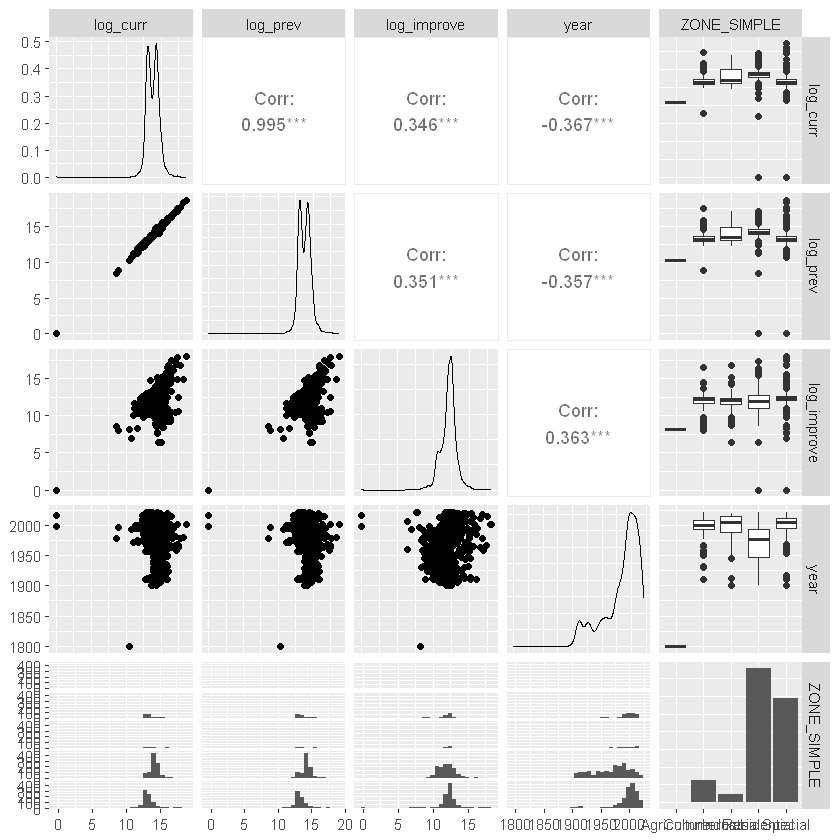

In [65]:
property_log <- property2 |>
                mutate(log_curr = log(CURRENT_LAND_VALUE),
                log_prev = log(PREVIOUS_LAND_VALUE),
                log_improve = log(PREVIOUS_IMPROVEMENT_VALUE),
                year = as.numeric(YEAR_BUILT)) |>
                select(log_curr, log_prev, log_improve, year, ZONE_SIMPLE)
ggpairs(property_log)

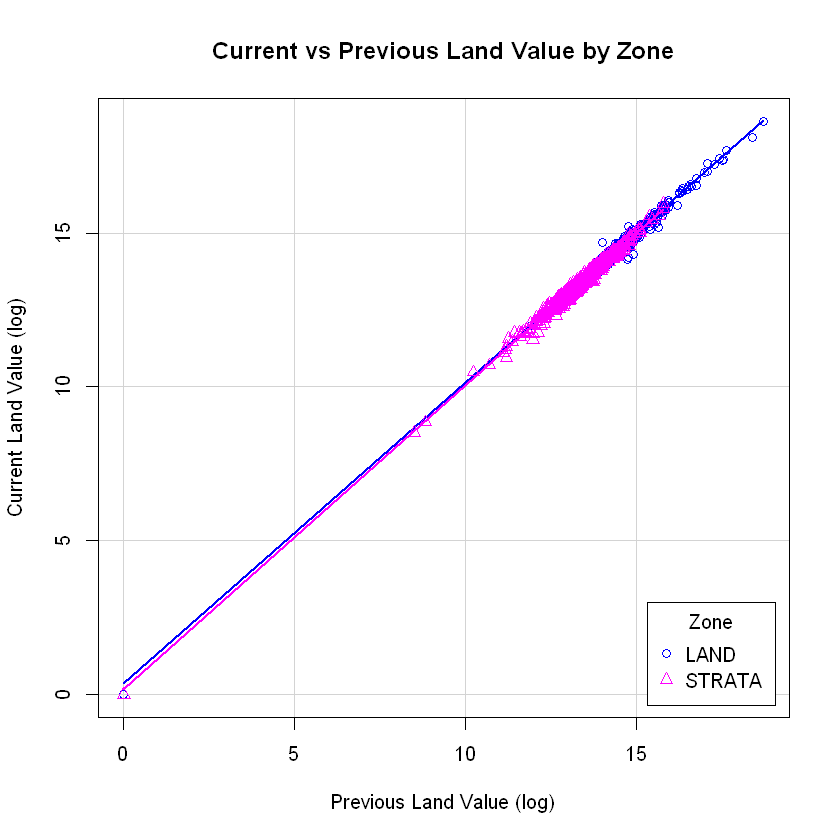

In [66]:
scatterplot(
    log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE)|LEGAL_TYPE, 
    smooth=FALSE, 
    by.groups=TRUE,
    xlab = "Previous Land Value (log)", 
    ylab = "Current Land Value (log)",
    main = "Current vs Previous Land Value by Zone",
    legend = list(title = "Zone", coords = "bottomright"),
    data = property2
    )

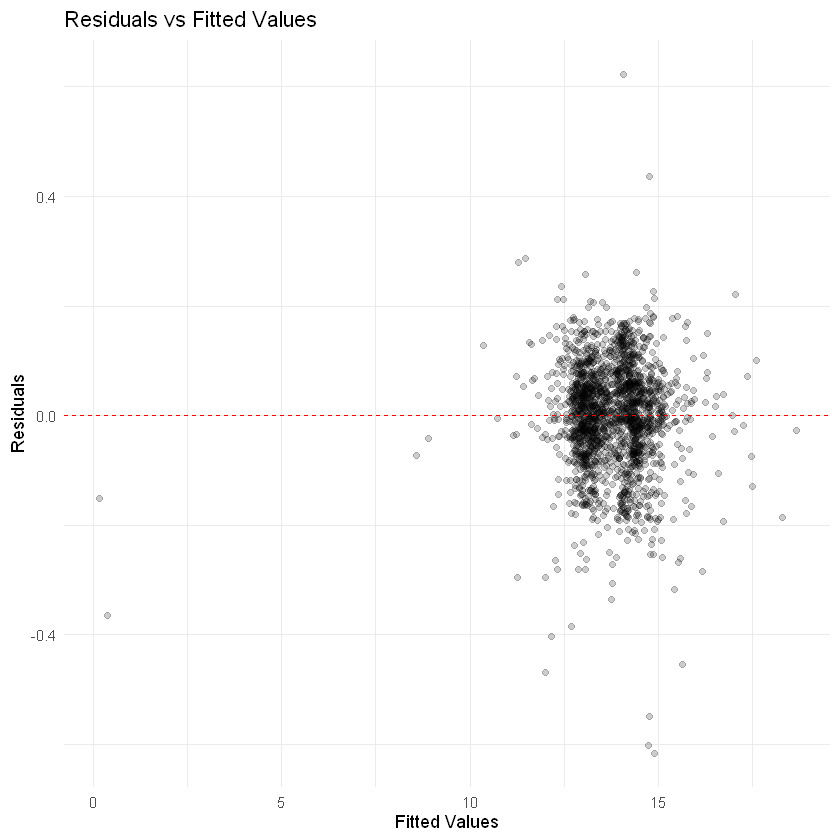

In [67]:
#ggplot2 for the red line
ggplot(data.frame(fitted = fit_int_legal$fitted.values, residuals = fit_int_legal$residuals),
       aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.2) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(x = "Fitted Values", 
       y = "Residuals",
       title = "Residuals vs Fitted Values") +
  theme_minimal()

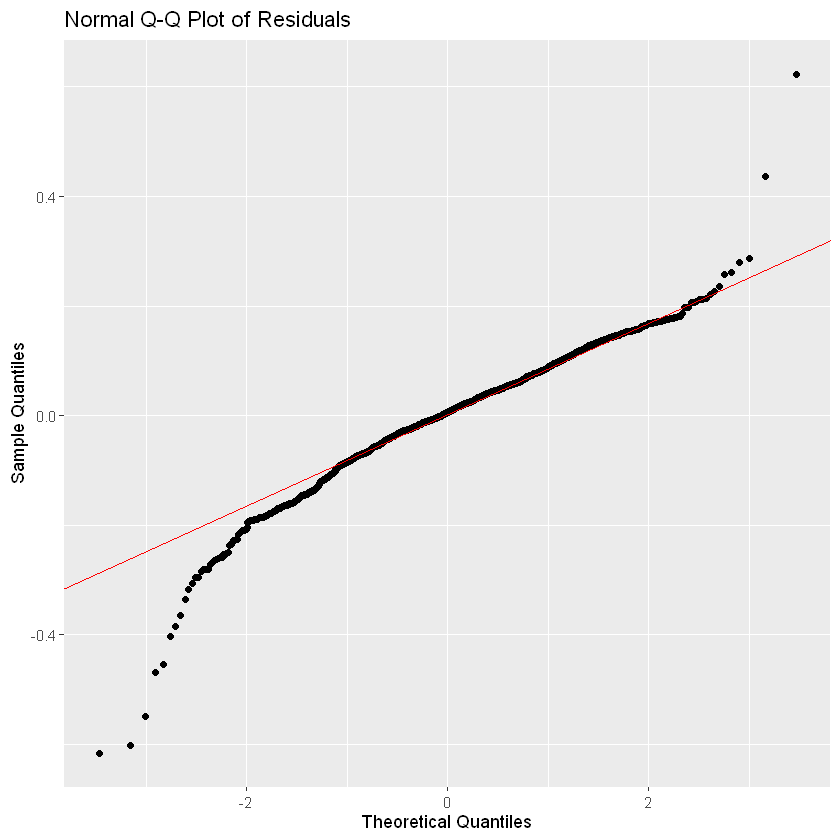

In [68]:
# ggplot2
ggplot(data.frame(resid = residuals(fit_int_legal)), aes(sample = resid)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  labs(
    title = "Normal Q-Q Plot of Residuals",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )